# Atmospheric profiles for Berton (2023) Figures 1–5

This notebook reproduces the prescribed atmospheric profiles used by the reference implementation in `cloud_rom.berton2023`:

- Figure 1: horizontal wind profile $U_a(z)$
- Figure 2: updraft profiles $W_a(z)$
- Figure 3: ambient temperature and dry-air pressure
- Figure 4: relative humidity and saturation ratios
- Figure 5: atmospheric infrared ratio $\eta_a(z)$


In [19]:
import matplotlib.pyplot as plt
import numpy as np

from cloud_rom import berton2023 as b

plt.rcParams.update({"figure.figsize": (6, 4), "axes.grid": True})


In [20]:
z_km = np.linspace(0, 20, 401)
z = [b.Q_(value, "km") for value in z_km]
atm = b.Atmosphere()


## Figure 1 — Atmospheric profile of horizontal wind

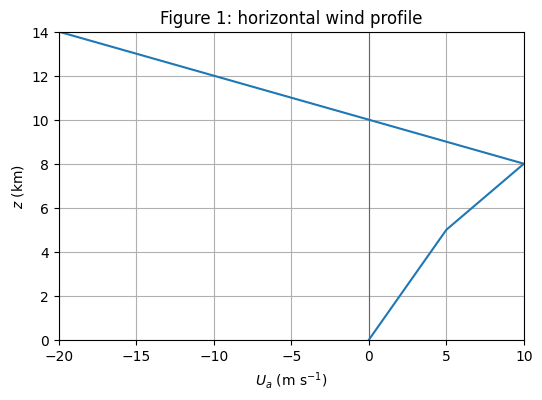

In [21]:
U = [atm.horizontal_wind(zi).to("m/s").magnitude for zi in z]

fig, ax = plt.subplots()
ax.plot(U, z_km)
ax.axvline(0, color="0.4", lw=0.8)
ax.set_xlabel(r"$U_a$ (m s$^{-1}$)")
ax.set_ylabel(r"$z$ (km)")
ax.set_title("Figure 1: horizontal wind profile")
ax.set_xlim((-20.0, 10.0))
ax.set_ylim((0.0, 14.0))
plt.show()


## Figure 2 — Atmospheric profiles of vertical wind/updraft

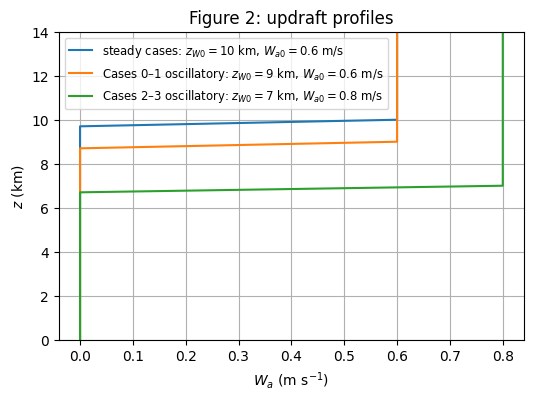

In [22]:
profiles = [
    ("steady cases: $z_{W0}=10$ km, $W_{a0}=0.6$ m/s", b.Atmosphere(W_a0=b.Q_(0.6, "m/s"), z_W0=b.Q_(10, "km"))),
    ("Cases 0–1 oscillatory: $z_{W0}=9$ km, $W_{a0}=0.6$ m/s", b.Atmosphere(W_a0=b.Q_(0.6, "m/s"), z_W0=b.Q_(9, "km"))),
    ("Cases 2–3 oscillatory: $z_{W0}=7$ km, $W_{a0}=0.8$ m/s", b.Atmosphere(W_a0=b.Q_(0.8, "m/s"), z_W0=b.Q_(7, "km"))),
]

fig, ax = plt.subplots()
for label, profile in profiles:
    W = [profile.updraft(zi).to("m/s").magnitude for zi in z]
    ax.plot(W, z_km, label=label)
ax.set_xlabel(r"$W_a$ (m s$^{-1}$)")
ax.set_ylabel(r"$z$ (km)")
ax.set_title("Figure 2: updraft profiles")
ax.set_ylim((0.0, 14.0))
ax.legend(fontsize="small")
plt.show()


## Figure 3 — Atmospheric profiles of temperature and pressure of dry air

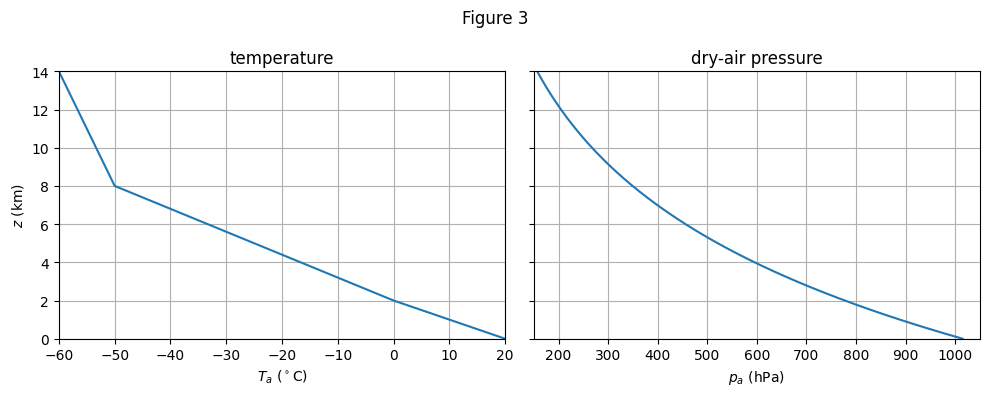

In [23]:
T_C = [atm.temperature(zi).to("degC").magnitude for zi in z]
p_hPa = [b.dry_air_pressure(zi).to("hPa").magnitude for zi in z]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax0.plot(T_C, z_km)
ax0.set_xlabel(r"$T_a$ ($^\circ$C)")
ax0.set_ylabel(r"$z$ (km)")
ax0.set_title("temperature")
ax0.set_ylim((0.0, 14.0))
ax0.set_xlim((-60.0, 20.0))

ax1.plot(p_hPa, z_km)
ax1.set_xlabel(r"$p_a$ (hPa)")
ax1.set_title("dry-air pressure")
ax1.set_ylim((0.0, 14.0))
ax1.set_xlim((150.0, 1050.0))
fig.suptitle("Figure 3")
fig.tight_layout()
plt.show()


## Figure 4 — Relative humidity and saturation ratios

The paper specifies $H_l=H_a$ as the ambient relative humidity with respect to liquid water.  We then invert Appendix B for $p_v$ and compute $H_i$, $S_l$, and $S_i$ from Eqs. (12)–(13).


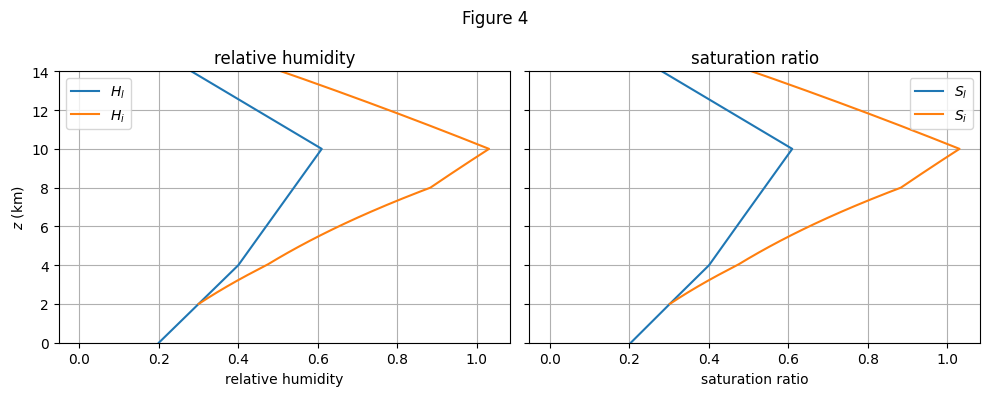

In [24]:
H_l = []
H_i = []
S_l = []
S_i = []
T_freezing = b.Q_(273.15, "K")

for zi in z:
    T = atm.temperature(zi)
    p_a = b.dry_air_pressure(zi)
    pvsl = b.saturation_pressure_liquid(T)
    pvsi = b.saturation_pressure_ice(T)
    Hl = atm.relative_humidity_profile(zi)
    pv = b.water_vapor_pressure_from_Hl(Hl, p_a, pvsl)
    p = p_a + pv
    sl, si = b.saturation_ratios(pv, pvsl, pvsi)
    _, hi = b.relative_humidities(pv, p, pvsl, pvsi)
    H_l.append(Hl)
    S_l.append(sl)

    # As in Berton (2023), Fig. 4, only plot ice-relative quantities where
    # Ta <= 273.15 K.  Above freezing the Sonntag ice formula is outside the
    # intended domain and gives pvsi > pvsl, which would make Hi < Hl.
    if T <= T_freezing:
        H_i.append(hi)
        S_i.append(si)
    else:
        H_i.append(np.nan)
        S_i.append(np.nan)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax0.plot(H_l, z_km, label=r"$H_l$")
ax0.plot(H_i, z_km, label=r"$H_i$")
ax0.set_xlabel("relative humidity")
ax0.set_ylabel(r"$z$ (km)")
ax0.set_title("relative humidity")
ax0.set_ylim((0.0, 14.0))
ax0.legend()

ax1.plot(S_l, z_km, label=r"$S_l$")
ax1.plot(S_i, z_km, label=r"$S_i$")
ax1.set_xlabel("saturation ratio")
ax1.set_title("saturation ratio")
ax1.set_ylim((0.0, 14.0))
ax1.legend()
fig.suptitle("Figure 4")
fig.tight_layout()
plt.show()


## Figure 5 — Atmospheric infrared ratio $\eta_a$

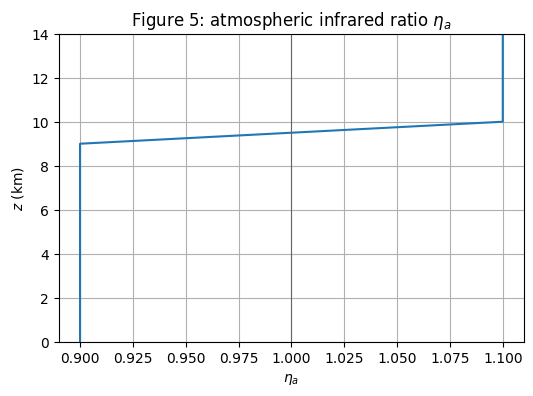

In [25]:
eta_a = [atm.atmospheric_eta(zi) for zi in z]

fig, ax = plt.subplots()
ax.plot(eta_a, z_km)
ax.axvline(1, color="0.4", lw=0.8)
ax.set_xlabel(r"$\eta_a$")
ax.set_ylabel(r"$z$ (km)")
ax.set_title(r"Figure 5: atmospheric infrared ratio $\eta_a$")
ax.set_ylim((0.0, 14.0))
plt.show()
